In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [63]:
len(words)

32033

In [64]:
from string import ascii_lowercase
stoi = {s: i+1 for i, s in enumerate(ascii_lowercase)}
stoi['$'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

In [65]:
block_size = 3

def build_dataset(words):
    X, y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '$':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_valid, y_valid = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [66]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g)
B1 = torch.randn(n_hidden,                           generator=g)
W2 = torch.randn((n_hidden, vocab_size),             generator=g)
B2 = torch.randn(vocab_size,                         generator=g)

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [67]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    hp_react = embeddings_concatenated @ W1 + B1
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.9184
  20000/ 200000: 2.5847
  30000/ 200000: 2.7859
  40000/ 200000: 2.0222
  50000/ 200000: 2.6171
  60000/ 200000: 2.3168
  70000/ 200000: 2.0853
  80000/ 200000: 2.2519
  90000/ 200000: 2.2718
 100000/ 200000: 2.0234
 110000/ 200000: 2.4689
 120000/ 200000: 1.9426
 130000/ 200000: 2.3817
 140000/ 200000: 2.3213
 150000/ 200000: 2.1416
 160000/ 200000: 2.2320
 170000/ 200000: 1.7736
 180000/ 200000: 2.0826
 190000/ 200000: 1.8465


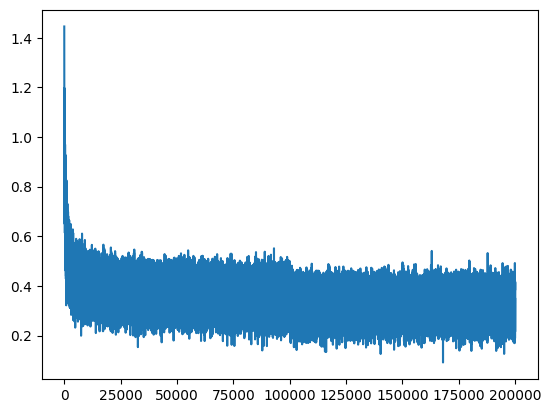

In [68]:
plt.plot(lossi)

In [69]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, y_train),
        'valid': (X_valid, y_valid),
        'test': (X_test, y_test),
    }[split]
    embeddings = C[x]
    h = torch.tanh(embeddings.view(embeddings.shape[0], -1) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')

train 2.1276261806488037
valid 2.1701834201812744


In [70]:
# Sample from the Model
g = torch.Generator().manual_seed(2147483647)
for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        embeddings = C[torch.tensor([context])]
        h = torch.tanh(embeddings.view(1, -1) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(itos[x] for x in out[:-1]))

dexzerioulius
rochi
ahnevin
matta
noluwan
kaida
samiyah
jaxhrusotai
moziellah
jacoreda


In [71]:
# The loss we can expect is -> At the worst case scenario all the 27 next characters probabilites are equal means they follow uniform distribution

print(-torch.tensor(1/27).log()) # for single sample
n = 32 # lets say
-torch.tensor(n*[1/27]).log().mean() # Same as single sample loss

tensor(3.2958)


tensor(3.2958)

In [72]:
# But in the training for the first epoch we got `0/ 200000: 27.8817` loss
# So there is something wrong in the initialization of parameters
# The loss we expect is to be tensor(3.2958) but instead we got tensor(27.8817)

In [73]:
# Lets take a uniform distribution example
logits_a = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # Uniform loss

logits_a = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # Low loss

logits_a = torch.tensor([0.0, 5.0, 0.0, 0.0])
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log() # Character character's predicted loss
print(probs, loss) # High loss

logits_a = torch.randn(4) * 10
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log()
print(logits_a, '\n',
      probs, '\n',
      loss)

logits_a = torch.randn(4) * 100
probs = torch.softmax(logits_a, dim=0)
loss = -probs[2].log()
print(logits_a, '\n',
      probs, '\n',
      loss)

tensor([0.2500, 0.2500, 0.2500, 0.2500]) tensor(1.3863)
tensor([0.0066, 0.0066, 0.9802, 0.0066]) tensor(0.0200)
tensor([0.0066, 0.9802, 0.0066, 0.0066]) tensor(5.0200)
tensor([  8.2034, -10.7974,  -7.6823,  -6.1025]) 
 tensor([1.0000e+00, 5.5986e-09, 1.2617e-07, 6.1241e-07]) 
 tensor(15.8856)
tensor([-268.5038,  -88.5884,  122.9368, -105.0899]) 
 tensor([0., 0., 1., 0.]) 
 tensor(-0.)


### Goal is to get a minimum loss at the initialization stage of training.

In [74]:
logits[0] # Here the logits are taking quite high values, thats why this creating the fake high loss at initialization after the first epoch, model will do backpropogation and then it will eventually get down to minimal loss because the logits will be updated much much equal to 0, 1, -1 like that.

tensor([ 7.8539,  3.3750,  3.3848,  3.5015,  4.5821,  3.9659,  1.5548,  3.0008,
         5.7546,  5.3703,  3.2080,  3.8544,  6.2126,  4.1155,  7.8451,  1.3288,
         2.4785, -1.1488,  5.4006,  4.3880,  3.8265,  3.7136,  3.2449,  2.8782,
         0.3357,  4.9563,  1.8350], grad_fn=<SelectBackward0>)

In [75]:
# The loss we expect roughly is to be tensor(3.2958) when all the logits are roughly equal and share a uniform distribution

In [117]:
n_emb = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb),                 generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden),     generator=g)
B1 = torch.randn(n_hidden,                           generator=g)
W2 = torch.randn((n_hidden, vocab_size),             generator=g) * 0.01
B2 = torch.randn(vocab_size,                         generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [118]:
max_steps = 200000
batch_size = 32
lossi = []

for epoch in range(max_steps):

    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size, ), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]

    # Forward Pass
    embeddings = C[X_batch]
    embeddings_concatenated = embeddings.view(embeddings.shape[0], -1)
    hp_react = embeddings_concatenated @ W1 + B1
    h = torch.tanh(hp_react)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y_batch)

    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update Step
    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # Track Status
    if epoch%10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # print(lossi)
    # break

      0/ 200000: 3.3221
  10000/ 200000: 2.1900
  20000/ 200000: 2.4196
  30000/ 200000: 2.6067
  40000/ 200000: 2.0601
  50000/ 200000: 2.4988
  60000/ 200000: 2.3902
  70000/ 200000: 2.1344
  80000/ 200000: 2.3369
  90000/ 200000: 2.1299
 100000/ 200000: 1.8329
 110000/ 200000: 2.2053
 120000/ 200000: 1.8540
 130000/ 200000: 2.4566
 140000/ 200000: 2.1879
 150000/ 200000: 2.1118
 160000/ 200000: 1.8956
 170000/ 200000: 1.8645
 180000/ 200000: 2.0326
 190000/ 200000: 1.8417


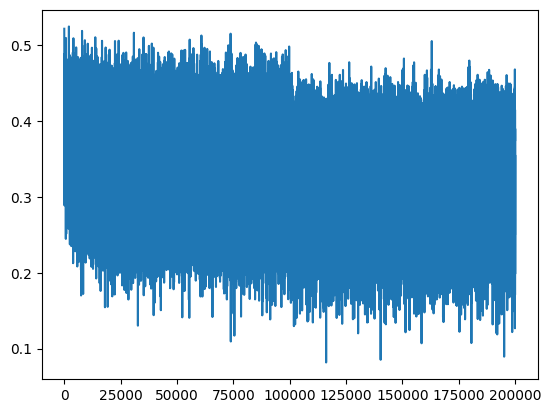

In [119]:
plt.plot(lossi)

In [120]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, y_train),
        'valid': (X_valid, y_valid),
        'test': (X_test, y_test),
    }[split]
    embeddings = C[x]
    h = torch.tanh(embeddings.view(embeddings.shape[0], -1) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')

train 2.069589138031006
valid 2.131074905395508


In [81]:
'''
for the first time
27.8817
train 2.1276261806488037
valid 2.1701834201812744

---------------------------------------------------------------------------------------------------------

{B2 * 0}, {W2 * 0} => 
3.2958 # Exactly what we are looking for because all the logits will be zero. so it is a uniform distribution.

{B2 * 0}, {W2 * 0.1} => 
4.2326

---------------------------------------------------------------------------------------------------------

{B2 * 0}, {W2 * 0.01} => 
3.221 # Closely to what we expected but it has little entropy in logits not exactly equal to zero.
train 2.069577217102051
valid 2.131200075149536

---------------------------------------------------------------------------------------------------------



 
'''


'\nfor the first time\n27.8817\ntrain 2.1276261806488037\nvalid 2.1701834201812744\n\n---------------------------------------------------------------------------------------------------------\n\n{B2 * 0}, {W2 * 0} => \n3.2958 # Exactly what we are looking for because all the logits will be zero. so it is a uniform distribution.\n\n{B2 * 0}, {W2 * 0.1} => \n4.2326\n\n---------------------------------------------------------------------------------------------------------\n\n{B2 * 0}, {W2 * 0.01} => \n3.221 # Closely to what we expected but it has little entropy in logits not exactly equal to zero.\ntrain 2.069577217102051\nvalid 2.131200075149536\n\n---------------------------------------------------------------------------------------------------------\n\n\n\n \n'

### Fixing Saturatied TanH Actiavation Function

In [82]:
# Now that we are done with the W2 and B2,
# Lets look at activations (h) and pre-activation (hp_react)
# h takes values many in extreme positions
# because
# hp_react (pre-activations) takes extreme values like -20 and 20
# we don't want that

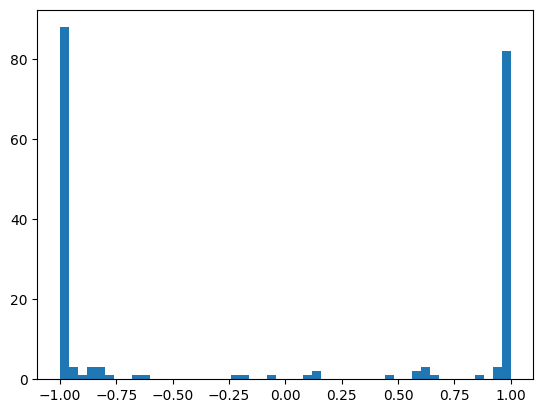

In [83]:
plt.hist(h.view(-1).tolist(), bins=50);

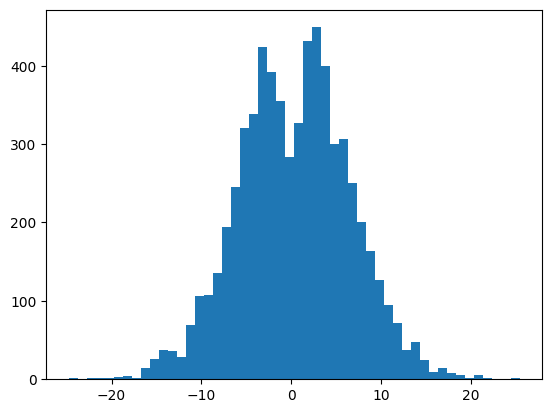

In [84]:
plt.hist(hp_react.view(-1).tolist(), bins=50);

## These pre-activation are very very broad